# 03: Analyze Stadium & Attendance Data

Produces the visualizations for the stadium/infrastructure half of the project:

1. A map of current stadiums, sized by capacity and colored by which league(s) play there.
2. How full each stadium is relative to its capacity.
3. Average NWSL home attendance by team.
4. NWSL average home attendance by season, by team.
5. Which teams are driving (or dragging down) league-wide attendance growth, and which specific matchups draw the biggest rivalry premium.
6. When (day of week, month) fans actually show up, and whether shared stadiums favor the MLS tenant.
7. Whether on-field success (points per game) predicts attendance, and which teams over/under-draw relative to their record -- for NWSL and for MLS.
8. Whether a new stadium coincides with a bump in attendance.
9. Whether NWSL is closing the public-interest gap with MLS.
10. Whether metro market size predicts attendance -- for NWSL and for MLS.
11. Confounding checks, then one OLS regression: what actually predicts attendance.

Uses the shared color theme in `plot_theme.py` so every chart in this repo reads as part of the same project.

**Inputs:** `data/processed/stadiums.csv`, `teams_clean.csv`, `games_clean.csv`, `star_player_seasons.csv`, `data/raw/time_series_mens_womens.csv` (metro population is a hand-built lookup, not a pulled dataset)
**Outputs:** figures saved to `output/`

In [38]:
import pandas as pd
import numpy as np
import plotly.express as px
import os
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from plot_theme import style_plotly_fig, NWSL_SEQUENTIAL

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
OUTPUT_DIR = os.path.join("..", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

stadiums = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "stadiums.csv"))
teams = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "teams_clean.csv"))
games = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "games_clean.csv"))
star_player_seasons = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "star_player_seasons.csv"))

print(f"Loaded: stadiums {stadiums.shape}, teams {teams.shape}, games {games.shape}, "
      f"star_player_seasons {star_player_seasons.shape}")


def fit_trend(x, y):
    """Slope/intercept via sklearn LinearRegression, r via numpy.corrcoef --
    used everywhere in this notebook that a chart needs a trendline + Pearson r."""
    model = LinearRegression().fit(np.asarray(x).reshape(-1, 1), y)
    slope = model.coef_[0]
    intercept = model.intercept_
    r = np.corrcoef(x, y)[0, 1]
    return slope, intercept, r

def parse_coefs(results_or_block, table_index=1, rows=None, drop_const=True):
    """Extract a coefficient dataframe for forest plotting."""
    if isinstance(results_or_block, list):
        R = pd.DataFrame(results_or_block,
                         columns=["vari", "coef", "std_err", "t", "p_val", "low_b", "up_b"])
        R[["coef", "std_err", "t", "p_val", "low_b", "up_b"]] = \
            R[["coef", "std_err", "t", "p_val", "low_b", "up_b"]].astype(float)
    else:
        R = results_or_block.summary().tables[table_index].data
        R = pd.DataFrame(R)
        R.columns = R.iloc[0]
        R = R.iloc[1:]
        if rows is not None:
            R = R.iloc[rows]
        R[R.columns[1:]] = R[R.columns[1:]].astype(float)
        R.columns = ["vari", "coef", "std_err", "t", "p_val", "low_b", "up_b"]

    if drop_const:
        R = R[R.vari.str.strip() != "const"]
    R = R.sort_values("coef", ascending=True).reset_index(drop=True)
    p = 0.1
    R["alpha"] = (R.p_val < 0.05) * (1 - p) + p
    return R

Loaded: stadiums (57, 38), teams (50, 8), games (7283, 23), star_player_seasons (21, 6)


## Map: current stadiums by capacity and league

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/3642495387.py:31: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "stadiums_map_by_capacity.png"))


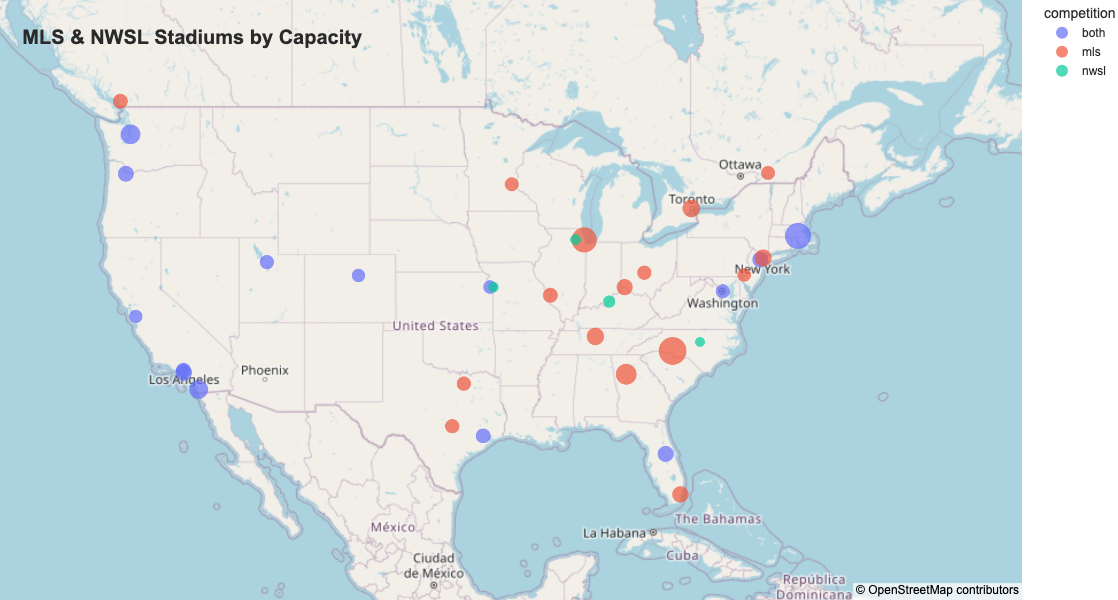

In [3]:
current_stadiums = stadiums[stadiums.primary_is_current == True].copy()
current_stadiums["capacity_clean"] = current_stadiums["capacity"].fillna(10000)

fig = px.scatter_map(
    current_stadiums,
    lat="latitude",
    lon="longitude",
    hover_name="stadium_name",
    color="competition",
    size="capacity_clean",
    size_max=20,
    zoom=3.2,
    map_style="open-street-map",
)

fig = style_plotly_fig(fig)
fig.update_layout(
    width=1000,
    height=600,
    margin={"r": 0, "t": 0, "l": 0, "b": 0},
    title={
        "text": "<b>MLS & NWSL Stadiums by Capacity</b>",
        "y": 0.95,
        "x": 0.02,
        "xanchor": "left",
        "yanchor": "top",
        "font": {"size": 20, "color": "#2a2a2a", "family": "Arial, sans-serif"},
    },
)

fig.write_image(os.path.join(OUTPUT_DIR, "stadiums_map_by_capacity.png"))
fig.show()


## How full are the stadiums?

Raw attendance numbers don't say whether a team is filling its building or rattling around in it. Utilization = 2025 (last complete season) average home attendance / the venue's seating capacity.

**Note:** several NWSL teams are the *secondary* tenant of a football-sized venue shared with an MLS or NFL team (Gillette Stadium, Lumen Field, Dick's Sporting Goods Park, PayPal Park, Shell Energy Stadium). Those venues' listed capacity is the full bowl, but teams routinely curtain off upper sections for a smaller soccer crowd. So utilization for those five teams is a **lower bound**, not literally how empty the building looked on game day.

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/769677280.py:62: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_capacity_utilization.png"))


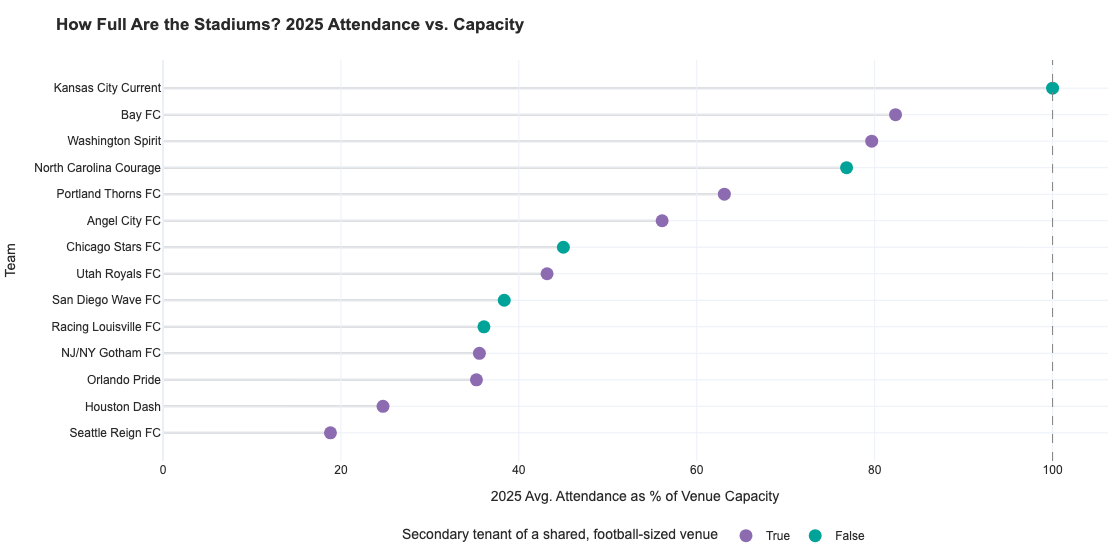

In [4]:
# 1. Current active NWSL teams and their 2025 average home attendance
active_teams_util = teams[(teams["league"] == "nwsl") & (teams["year_of_death"].isna())].copy()

nwsl_games_util = games[games["league"] == "nwsl"].dropna(subset=["attendance", "home_team_id"])
att_2025 = (
    nwsl_games_util[nwsl_games_util["season_name"] == 2025]
    .groupby("home_team_id")["attendance"]
    .mean()
    .rename("avg_attendance_2025")
)

# 2. Each team's CURRENT stadium: checking both primary AND secondary tenant slots.
# Many NWSL teams are secondary tenants, so have to look ip both
current_venues = stadiums[stadiums["primary_is_current"] | stadiums["secondary_is_current"]]
tenant_rows = []
for _, venue in current_venues.iterrows():
    if pd.notna(venue["primary_team_id"]) and venue["primary_is_current"]:
        tenant_rows.append({"team_id": venue["primary_team_id"], "stadium_name": venue["stadium_name"],
                             "capacity": venue["capacity"], "tenant_rank": "primary"})
    if pd.notna(venue["secondary_team_id"]) and venue["secondary_is_current"]:
        tenant_rows.append({"team_id": venue["secondary_team_id"], "stadium_name": venue["stadium_name"],
                             "capacity": venue["capacity"], "tenant_rank": "secondary"})
current_tenants = pd.DataFrame(tenant_rows)

utilization = (
    active_teams_util.merge(current_tenants, on="team_id", how="left")
    .merge(att_2025, left_on="team_id", right_index=True, how="left")
    .dropna(subset=["capacity", "avg_attendance_2025"])
)
utilization["utilization_pct"] = utilization["avg_attendance_2025"] / utilization["capacity"] * 100
utilization["shared_nfl_sized_venue"] = utilization["tenant_rank"] == "secondary"
utilization = utilization.sort_values("utilization_pct")

# 3. Plot: lollipop / dot chart, capped visually at 100% with a sellout reference line
fig = px.scatter(
    utilization,
    x="utilization_pct", y="team_name",
    color="shared_nfl_sized_venue",
    color_discrete_map={True: "#8C6BB1", False: "#00A398"},
    hover_data={"stadium_name": True, "capacity": ":,", "avg_attendance_2025": ":,.0f",
                "shared_nfl_sized_venue": False, "utilization_pct": ":.0f"},
    labels={"utilization_pct": "2025 Avg. Attendance as % of Venue Capacity", "team_name": "Team",
            "shared_nfl_sized_venue": "Secondary tenant of a shared, football-sized venue"},
    title="<b>How Full Are the Stadiums? 2025 Attendance vs. Capacity</b>",
)
fig.update_traces(marker={"size": 13})
# Lollipop stems
for _, row in utilization.iterrows():
    fig.add_shape(
        type="line", x0=0, x1=row["utilization_pct"], y0=row["team_name"], y1=row["team_name"],
        line={"color": "#cccccc", "width": 2}, layer="below",
    )
fig.add_vline(x=100, line_width=1, line_dash="dash", line_color="gray")

fig = style_plotly_fig(fig)
fig.update_layout(
    height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10},
    legend={"orientation": "h", "y": -0.15, "x": 0.5, "xanchor": "center"},
)
# Reorder color-grouping
fig.update_yaxes(categoryorder="array", categoryarray=utilization["team_name"].tolist())
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_capacity_utilization.png"))
fig.show()

## When do fans show up? Scheduling patterns

Initially saw massive attendence increase for Monday games, but after second look, these were all West Coast Sunday night games. To fix this, converting every game to its native time one. Most of those games were actually played on Monday. Not 100% fool-proof for daylight savings time, but mostly matches the NWSL's March-November season.

Even after the fix, a handful of dark "Monday" cells remain in the heatmap below -- checked those individually too, and they're real (Memorial Day games, and several Angel City FC prime-time Monday showcases that drew 15-22k), just a small sample of a few games rather than a broad weekly pattern. The hover on each cell shows the game count so you can tell a real pattern from a thin one.

Dropped 39 games at stadiums with no location metadata


/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/2845591875.py:60: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_scheduling_heatmap.png"))


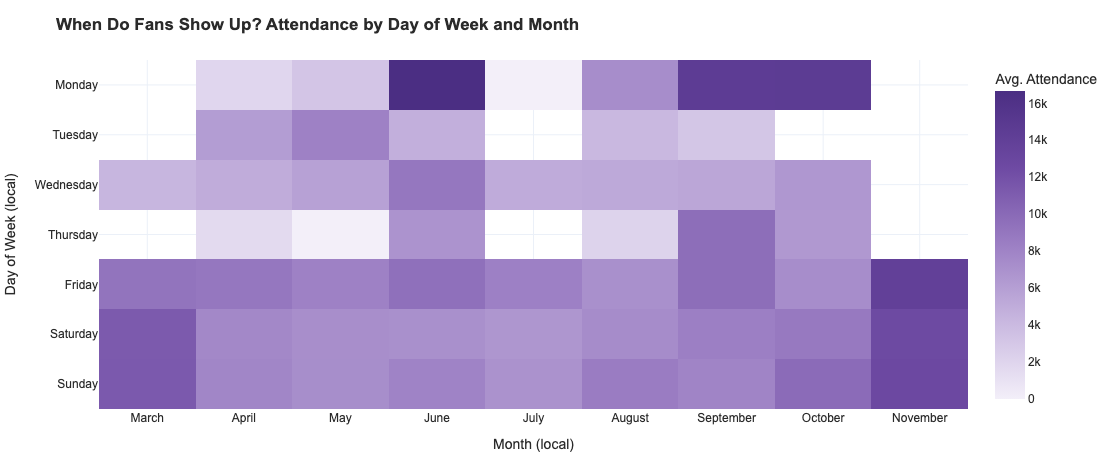

In [5]:
# 1. Approximate local-time UTC offset per stadium (seasonal/DST offset, since NWSL plays
STATE_OFFSET = {
    "California": -7, "Washington": -7, "Oregon": -7,
    "Utah": -6, "Colorado": -6,
    "Texas": -5, "Kansas": -5, "Missouri": -5, "Illinois": -5,
    "Ohio": -4, "Kentucky": -4, "New Jersey": -4, "Pennsylvania": -4,
    "North Carolina": -4, "Florida": -4, "Maryland": -4, "Massachusetts": -4,
    "District of Columbia": -4, "New York": -4,
}
# A handful of stadiums have no city/province in the wiki-merged table, filled in by hand
STADIUM_OFFSET_OVERRIDE = {
    "Field of Legends": -5, "Northwestern Stadium": -5, "Snapdragon Stadium": -7,
    "CPKC Stadium": -5, "Jordan Field": -5, "Rochester Rinos Stadium": -4,
    "UW Medicine Pitch at Memorial Stadium": -7, "Osceola Heritage Park": -4,
    "Moda Field": -7, "Yurcak Field": -4,
}

stadium_offsets = stadiums[["stadium_id", "stadium_name", "province"]].copy()
stadium_offsets["utc_offset"] = (
    stadium_offsets["stadium_name"].map(STADIUM_OFFSET_OVERRIDE)
    .fillna(stadium_offsets["province"].map(STATE_OFFSET))
)

# 2. Convert each game to local kickoff time
schedule = games[games["league"] == "nwsl"].dropna(subset=["attendance", "stadium_id"]).merge(
    stadium_offsets[["stadium_id", "utc_offset"]], on="stadium_id", how="left",
)
n_dropped = schedule["utc_offset"].isna().sum()
schedule = schedule.dropna(subset=["utc_offset"])
schedule["date_time_utc"] = pd.to_datetime(schedule["date_time_utc"])
schedule["local_dt"] = schedule["date_time_utc"] + pd.to_timedelta(schedule["utc_offset"], unit="h")
schedule["day_of_week"] = schedule["local_dt"].dt.day_name()
schedule["month"] = schedule["local_dt"].dt.month_name()

print(f"Dropped {n_dropped} games at stadiums with no location metadata")

# 3. Heatmap: avg attendance by day-of-week x month (local time)
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = ["March", "April", "May", "June", "July", "August", "September", "October", "November"]

heat_pivot = schedule.pivot_table(index="day_of_week", columns="month", values="attendance", aggfunc="mean")
heat_pivot = heat_pivot.reindex(index=dow_order, columns=[m for m in month_order if m in heat_pivot.columns])
count_pivot = schedule.pivot_table(index="day_of_week", columns="month", values="game_id", aggfunc="count")
count_pivot = count_pivot.reindex(index=dow_order, columns=heat_pivot.columns)

fig = px.imshow(
    heat_pivot,
    color_continuous_scale=NWSL_SEQUENTIAL,
    aspect="auto",
    labels={"color": "Avg. Attendance", "x": "Month (local)", "y": "Day of Week (local)"},
    title="<b>When Do Fans Show Up? Attendance by Day of Week and Month</b>",
)
# Overlay game counts so a reader can see which cells are thin samples- playoffs, weekday rarities
fig.update_traces(
    customdata=count_pivot.values,
    hovertemplate="%{y}, %{x}<br>Avg. attendance: %{z:,.0f}<br>Games: %{customdata}<extra></extra>",
)
fig = style_plotly_fig(fig)
fig.update_layout(height=460, margin={"t": 60, "b": 40, "l": 10, "r": 10})
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_scheduling_heatmap.png"))
fig.show()

### Do shared stadiums prioritize the MLS tenant?

14 current stadiums host both an MLS and an NWSL team. At 13 of those 14, the MLS team is the **primary** (senior) tenant and the NWSL team is secondary. The one exception is Snapdragon Stadium, where San Diego Wave FC (2023) arrived before San Diego FC's MLS expansion team (2025).

Since both tenants play at the exact same venue, this comparison doesn't need local-time conversion. The question: does the NWSL tenant get pushed into the worse days/times while the MLS tenant gets the prime slots?

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/3896432290.py:35: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_shared_stadium_scheduling.png"))


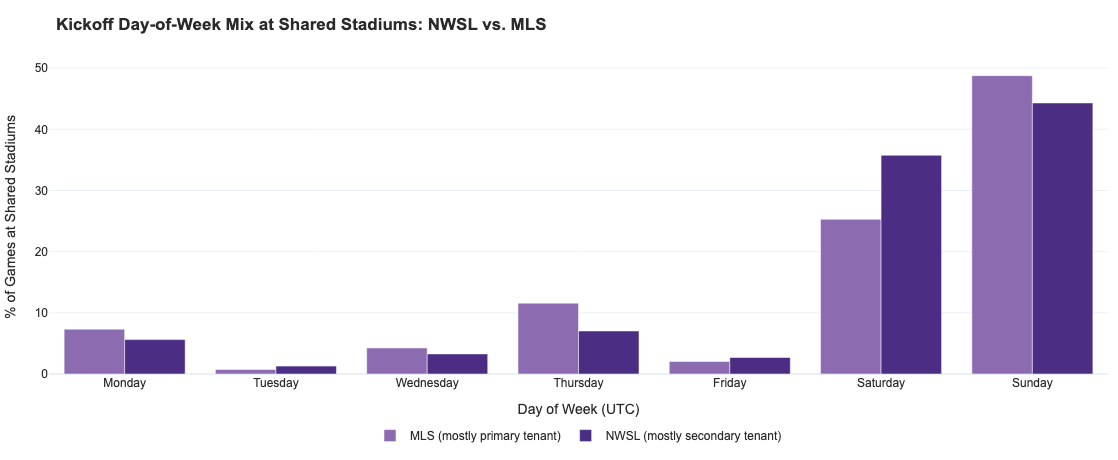

In [6]:
# 1. Current stadiums shared by both leagues
shared_stadiums = stadiums[
    (stadiums["competition"] == "both") & (stadiums["primary_is_current"] | stadiums["secondary_is_current"])
]
shared_stadium_ids = shared_stadiums["stadium_id"].tolist()

# 2. All games (any season) played at those stadiums, by either league (raw UTC)
shared_games = games[games["stadium_id"].isin(shared_stadium_ids) & games["league"].isin(["nwsl", "mls"])].copy()
shared_games["date_time_utc"] = pd.to_datetime(shared_games["date_time_utc"])
shared_games["day_of_week"] = shared_games["date_time_utc"].dt.day_name()

dow_share = (
    shared_games.groupby(["league", "day_of_week"]).size()
    .rename("games").reset_index()
)
dow_share["pct"] = dow_share["games"] / dow_share.groupby(dow_share["league"])["games"].transform("sum") * 100
dow_share["league_label"] = dow_share["league"].map({"nwsl": "NWSL (mostly secondary tenant)", "mls": "MLS (mostly primary tenant)"})

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig = px.bar(
    dow_share,
    x="day_of_week", y="pct", color="league_label",
    barmode="group",
    category_orders={"day_of_week": dow_order},
    color_discrete_map={"NWSL (mostly secondary tenant)": "#4B2E83", "MLS (mostly primary tenant)": "#8C6BB1"},
    labels={"pct": "% of Games at Shared Stadiums", "day_of_week": "Day of Week (UTC)", "league_label": ""},
    title="<b>Kickoff Day-of-Week Mix at Shared Stadiums: NWSL vs. MLS</b>",
)
fig = style_plotly_fig(fig)
fig.update_layout(
    height=460, margin={"t": 60, "b": 40, "l": 10, "r": 10},
    legend={"orientation": "h", "y": -0.15, "x": 0.5, "xanchor": "center"},
)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_shared_stadium_scheduling.png"))
fig.show()

**The data doesn't support the "MLS gets priority" hypothesis, at least not on day-of-week.** Potential for deeper analysis of prime-time slots.

## NWSL average home attendance by team

In [7]:
nwsl_games = games[games.league == "nwsl"].copy()
nwsl_teams = teams[teams.league == "nwsl"].copy()

# 1. Drop missing attendance rows
att_df = nwsl_games.dropna(subset=["attendance", "home_team_id"]).copy()

# 2. Merge with nwsl_teams to get team names
att_df = att_df.merge(
    nwsl_teams[["team_id", "team_name"]],
    left_on="home_team_id", right_on="team_id", how="left",
)

# 3. Group by team_name
team_summary = att_df.groupby("team_name").agg(
    avg_attendance=("attendance", "mean"),
    games_recorded=("game_id", "count"),
).reset_index()

# 4. Star recently-expanded teams (<=3 seasons) 
seasons_played = att_df.groupby("team_name")["season_name"].nunique()
team_summary["seasons_played"] = team_summary["team_name"].map(seasons_played)
team_summary["recent_expansion"] = team_summary["seasons_played"] <= 3
team_summary["team_label"] = team_summary["team_name"] + team_summary["recent_expansion"].map({True: " ★", False: ""})

# 5. Plot
fig = px.bar(
    team_summary.sort_values(by="avg_attendance", ascending=True),
    x="avg_attendance",
    y="team_label",
    orientation="h",
    color="avg_attendance",
    title="<b>Average NWSL Home Attendance by Team (Excluding Missing Records)</b>",
    labels={"avg_attendance": "Average Attendance", "team_label": "Team Name"},
    hover_data={"games_recorded": True, "seasons_played": True, "avg_attendance": ":.0f"},
    color_continuous_scale=NWSL_SEQUENTIAL,
)

fig = style_plotly_fig(fig)
fig.update_xaxes(title_text="Average Attendance<br><span style='font-size:11px;color:#666666'>★ = recently expanded (≤ 3 seasons played) or folded</span>")
fig.update_layout(margin={"t": 50, "b": 70, "l": 10, "r": 10}, height=540)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_avg_attendance_by_team.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/2206895074.py:41: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_avg_attendance_by_team.png"))


## NWSL average home attendance by season

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/3551396341.py:15: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_avg_attendance_by_season.png"))


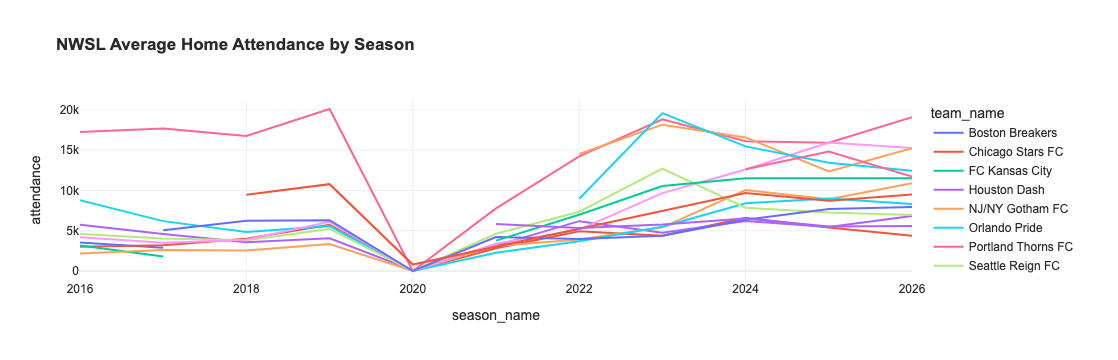

In [8]:
season_team_avg = (
    att_df.groupby(["season_name", "team_name"])["attendance"]
    .mean()
    .reset_index()
)

fig = px.line(
    season_team_avg,
    x="season_name",
    y="attendance",
    color="team_name",
    title="<b>NWSL Average Home Attendance by Season</b>",
)
fig = style_plotly_fig(fig)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_avg_attendance_by_season.png"))
fig.show()


## League growth: which teams are driving attendance gains

### The Away Draw Lift

For each team, compare its average attendance on the road to the host's own baseline home attendance **that same season** (not the host's career average, which unfairly favors visitors who happened to play a fast-growing host early on, or against one that hadn't expanded its stadium yet):

$$\text{Away Lift}_i = \frac{1}{N}\sum_{j \neq i} (\text{Attendance}_{j \text{ vs } i,\ \text{season } s} - \text{Mean Home Attendance}_{j,\ \text{season } s})$$

A positive lift means team $i$ draws bigger-than-usual crowds when it visits other stadiums. This is a sign it pulls fans league-wide, not just at home.

Two adjustments vs. a naive version of this metric:
- **Folded teams are dropped** (Western New York Flash, Boston Breakers, FC Kansas City)
- **Recently-expanded teams (≤3 seasons played) are starred (★)** because riding the wave of novelty and modern-day league growth.

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/138031319.py:68: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_away_draw_lift.png"))


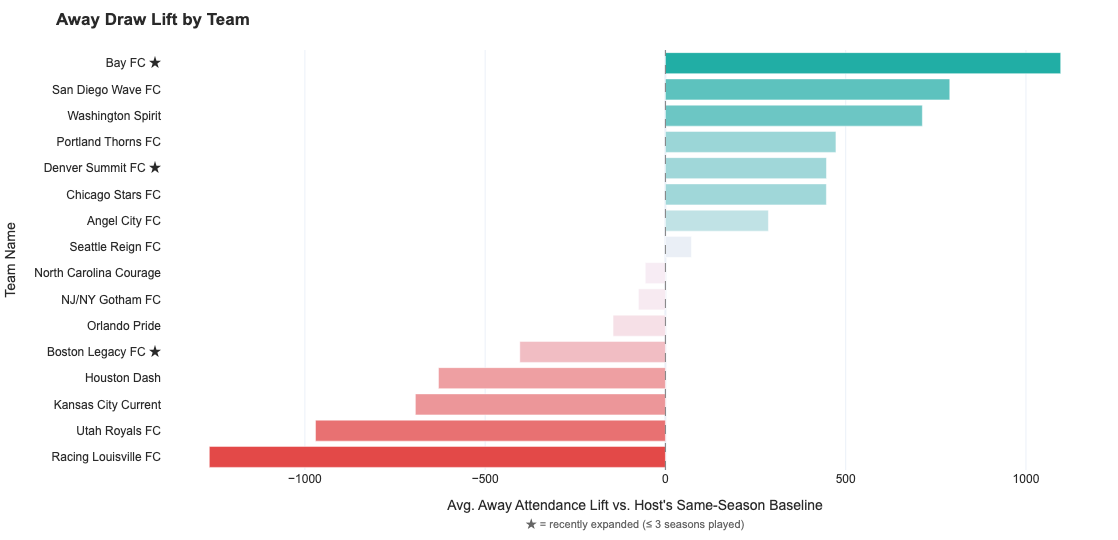

In [9]:
# 1. Drop folded teams
active_teams = nwsl_teams[nwsl_teams["year_of_death"].isna()].copy()

away_df = nwsl_games.dropna(subset=["attendance", "home_team_id", "away_team_id"]).copy()
away_df = away_df[
    away_df["home_team_id"].isin(active_teams["team_id"])
    & away_df["away_team_id"].isin(active_teams["team_id"])
]

away_df = away_df.merge(
    active_teams[["team_id", "team_name"]],
    left_on="home_team_id", right_on="team_id", how="left",
).rename(columns={"team_name": "home_team_name"}).drop(columns="team_id")

away_df = away_df.merge(
    active_teams[["team_id", "team_name"]],
    left_on="away_team_id", right_on="team_id", how="left",
).rename(columns={"team_name": "away_team_name"}).drop(columns="team_id")

# 2. Host baseline computed within each season -> was previously biasing expansion teams
season_host_baseline = (
    away_df.groupby(["season_name", "home_team_name"])["attendance"]
    .mean()
    .rename("host_season_baseline")
)
away_df = away_df.join(season_host_baseline, on=["season_name", "home_team_name"])

# 3. Lift = how much a game's attendance beat the host's usual home draw
away_df["lift"] = away_df["attendance"] - away_df["host_season_baseline"]

away_lift = (
    away_df.groupby("away_team_name")
    .agg(away_lift=("lift", "mean"), games_recorded=("game_id", "count"))
    .reset_index()
    .rename(columns={"away_team_name": "team_name"})
)

# 4. Flag recently-expanded teams (small away sample) so any bias shows up instead of hiding
seasons_played = away_df.groupby("away_team_name")["season_name"].nunique()
away_lift["seasons_played"] = away_lift["team_name"].map(seasons_played)
away_lift["recent_expansion"] = away_lift["seasons_played"] <= 3
away_lift["team_label"] = away_lift["team_name"] + away_lift["recent_expansion"].map({True: " ★", False: ""})
away_lift = away_lift.sort_values("away_lift")

# 5. Plot
fig = px.bar(
    away_lift,
    x="away_lift",
    y="team_label",
    orientation="h",
    color="away_lift",
    color_continuous_scale=["#E34948", "#F8F4FC", "#00A398"],
    color_continuous_midpoint=0,
    title="<b>Away Draw Lift by Team</b>",
    labels={"away_lift": "Avg. Attendance Lift vs. Host's Baseline", "team_label": "Team Name"},
    hover_data={"games_recorded": True, "seasons_played": True, "away_lift": ":.0f"},
)
fig = style_plotly_fig(fig)
fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="gray")
# Small-sample size note
fig.update_xaxes(
    title_text=(
        "Avg. Away Attendance Lift vs. Host's Same-Season Baseline"
        "<br><span style='font-size:11px;color:#666666'>★ = recently expanded (≤ 3 seasons played)</span>"
    )
)
fig.update_layout(margin={"t": 50, "b": 70, "l": 10, "r": 10}, height=540, coloraxis_showscale=False)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_away_draw_lift.png"))
fig.show()

### Rivalry premium: which specific matchups draw a crowd?

Same lift idea as above (attendance vs. the host's own same-season baseline), but now computed per **specific matchup** (home team × away team) instead of averaged across all of a team's road games. 

Restricted to matchups with **at least 8 meetings** to keep this from being dominated by a 2-3 game fluke -> 73 of the 231 possible matchups clear that bar. Top rivalry is the well-established Cascadia Rivalry.

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/3072603593.py:28: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_rivalry_premium.png"))


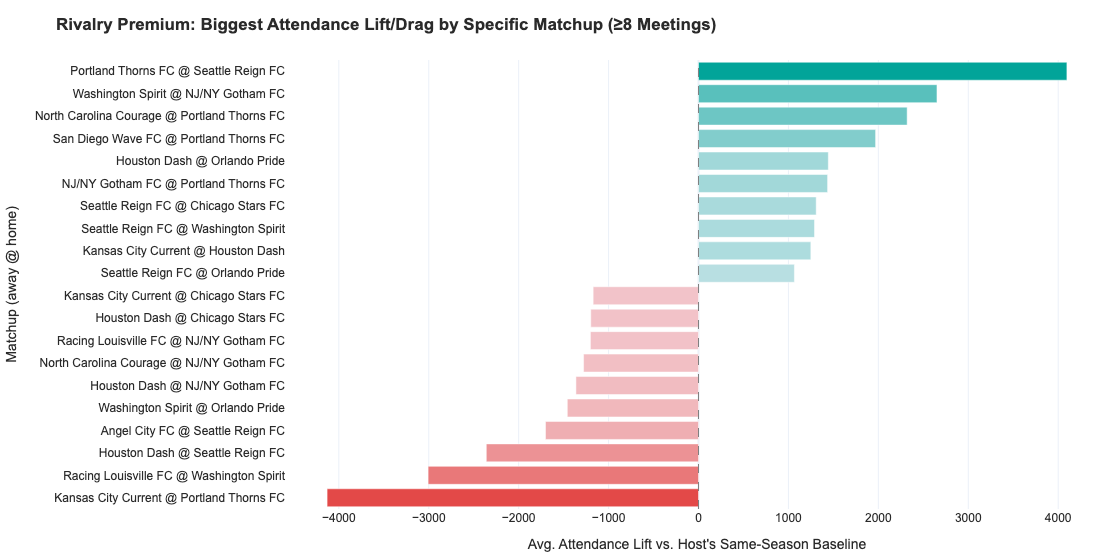

In [10]:
matchup_lift = (
    away_df.groupby(["home_team_name", "away_team_name"])
    .agg(lift=("lift", "mean"), meetings=("lift", "count"))
    .reset_index()
)
matchup_lift = matchup_lift[matchup_lift["meetings"] >= 8].copy()
matchup_lift["matchup"] = matchup_lift["away_team_name"] + " @ " + matchup_lift["home_team_name"]

top_bottom = pd.concat([
    matchup_lift.nlargest(10, "lift"),
    matchup_lift.nsmallest(10, "lift"),
]).sort_values("lift")

fig = px.bar(
    top_bottom,
    x="lift", y="matchup",
    orientation="h",
    color="lift",
    color_continuous_scale=["#E34948", "#F8F4FC", "#00A398"],
    color_continuous_midpoint=0,
    hover_data={"meetings": True, "lift": ":.0f"},
    labels={"lift": "Avg. Attendance Lift vs. Host's Same-Season Baseline", "matchup": "Matchup (away @ home)"},
    title="<b>Rivalry Premium: Biggest Attendance Lift/Drag by Specific Matchup (≥8 Meetings)</b>",
)
fig = style_plotly_fig(fig)
fig.add_vline(x=0, line_width=1, line_dash="dash", line_color="gray")
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10}, coloraxis_showscale=False)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_rivalry_premium.png"))
fig.show()

### Current-team summary table

- **Career avg. attendance**: per-game average across all of a team's completed seasons, **excluding 2020** (empty COVID stadiums would drag it down unrepresentatively).
- **CAGR**: compound annual growth rate in per-game attendance from the team's **debut season to 2025** (the last fully-completed season). Undefined (N/A) for teams whose only season so far is the in-progress 2026.
- **2025 YoY %**:  the most recent complete-season change (2025 vs. 2024).
- **Share of league attendance (2025)**: the team's share of total NWSL home attendance in 2025, i.e. a level/size measure, not a growth measure.
- **2026 (partial)**: this season's per-game average so far, shown separately rather than blended into the numbers above, since 2026 isn't finished.

Per the away-lift chart, teams with **≤ 3 completed seasons are starred (★)** because their CAGR/YoY numbers rest on very little history and should be read with that caveat.

In [11]:
# 1. Base: per-game & total attendance, per active team per season
active_att = att_df[att_df["team_name"].isin(active_teams["team_name"])].copy()
season_stats = (
    active_att.groupby(["season_name", "team_name"])["attendance"]
    .agg(avg_attendance="mean", total_attendance="sum", games="count")
    .reset_index()
)

complete_seasons = season_stats[season_stats["season_name"] <= 2025]
season_2026 = season_stats[season_stats["season_name"] == 2026]

# 2. Career avg. attendance: all completed seasons, excluding 2020 and 2021 (see markdown above)
career_avg = (
    complete_seasons[(complete_seasons["season_name"] != 2020) & (complete_seasons["season_name"] != 2021)]
    .groupby("team_name")["avg_attendance"]
    .mean()
    .rename("career_avg_attendance")
)

# 3. CAGR: debut season -> 2025 
debut = (
    complete_seasons.sort_values("season_name")
    .groupby("team_name")
    .first()[["season_name", "avg_attendance"]]
    .rename(columns={"season_name": "debut_season", "avg_attendance": "debut_avg"})
)
latest_2025 = complete_seasons[complete_seasons["season_name"] == 2025].set_index("team_name")["avg_attendance"]
prior_2024 = complete_seasons[complete_seasons["season_name"] == 2024].set_index("team_name")["avg_attendance"]

summary = active_teams.set_index("team_name")[["expansion_year"]].join(
    [debut, career_avg]
)
summary["latest_avg_2025"] = latest_2025
summary["years_active"] = 2025 - summary["debut_season"]
summary["cagr"] = ((summary["latest_avg_2025"] / summary["debut_avg"]) ** (1 / summary["years_active"])) - 1
summary.loc[summary["years_active"] <= 0, "cagr"] = None  # debut IS 2025, or no completed season yet

# 4. Most recent complete-season YoY % (2025 vs 2024)
summary["yoy_2025_pct"] = (latest_2025 / prior_2024 - 1) * 100

# 5. Share of league attendance in 2025 (level, not growth)
total_2025 = complete_seasons[complete_seasons["season_name"] == 2025].set_index("team_name")["total_attendance"]
summary["share_of_league_2025_pct"] = (total_2025 / total_2025.sum()) * 100

# 6. 2026 partial season, kept separate rather than blended into the numbers above
p26 = season_2026.set_index("team_name")[["avg_attendance", "games"]].rename(
    columns={"avg_attendance": "avg_2026_partial", "games": "games_2026"}
)
summary = summary.join(p26)

# 7. Seasons played (through 2025)
seasons_played = complete_seasons.groupby("team_name")["season_name"].nunique().rename("seasons_played")
summary = summary.join(seasons_played)
summary["seasons_played"] = summary["seasons_played"].fillna(0).astype(int)
summary["recent_expansion"] = summary["seasons_played"] <= 3

summary = summary.reset_index().rename(columns={"team_name": "Team"})
summary["Team"] = summary["Team"] + summary["recent_expansion"].map({True: " ★", False: ""})

display_cols = {
    "Team": "Team",
    "career_avg_attendance": "Career Avg. Attendance (excl. 2020)",
    "cagr": "CAGR (debut → 2025)",
    "yoy_2025_pct": "2025 YoY %",
    "share_of_league_2025_pct": "Share of League Attendance, 2025 (%)",
    "avg_2026_partial": "2026 Avg. (partial season)",
    "seasons_played": "Seasons Played (through 2025)",
}
team_table = summary[list(display_cols.keys())].rename(columns=display_cols)
team_table = team_table.sort_values("Share of League Attendance, 2025 (%)", ascending=False).reset_index(drop=True)

team_table.to_csv(os.path.join(OUTPUT_DIR, "nwsl_team_summary_table.csv"), index=False)

styled = team_table.style.format({
    "Career Avg. Attendance (excl. 2020)": "{:,.0f}",
    "CAGR (debut → 2025)": "{:+.1%}",
    "2025 YoY %": "{:+.1f}%",
    "Share of League Attendance, 2025 (%)": "{:.1f}%",
    "2026 Avg. (partial season)": "{:,.0f}",
}, na_rep="N/A").set_caption("★ = ≤ 3 completed seasons (through 2025) -- small-sample estimate")
styled

,Team,Career Avg. Attendance (excl. 2020),CAGR (debut → 2025),2025 YoY %,"Share of League Attendance, 2025 (%)",2026 Avg. (partial season),Seasons Played (through 2025)
0,Washington Spirit,"7,625",+16.0%,+26.6%,13.1%,"15,259",10
1,Portland Thorns FC,"17,101",-0.9%,-1.1%,11.4%,"19,082",10
2,Bay FC ★,"13,721",+17.5%,+17.5%,9.9%,"11,731",2
3,San Diego Wave FC,"14,359",+14.4%,-13.2%,9.0%,"12,452",4
4,Kansas City Current,"10,130",+32.2%,+0.0%,8.3%,"11,500",5
5,Angel City FC,"15,394",-5.2%,-25.5%,8.2%,"15,237",4
6,Orlando Pride,"6,494",+0.2%,+6.9%,7.4%,"8,321",10
7,NJ/NY Gotham FC,"4,864",+17.0%,-11.5%,5.9%,"10,900",10
8,Utah Royals FC,"9,660",-1.2%,-9.8%,5.8%,"9,477",5
9,North Carolina Courage,"5,716",+5.4%,+20.8%,5.1%,"7,949",9


## Why do some teams draw better than others?

### Does winning fill the stands?

For every active team's completed regular seasons (2016–2025, **2020 excluded** for the same COVID reason as above, **playoff/knockout games excluded** so the record reflects the regular-season product fans actually bought season tickets for), plot **points per game** (3 win / 1 draw / 0 loss) against that team's **average home attendance** that season (one dot per team-season).

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/859306976.py:81: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_success_vs_attendance.png"))


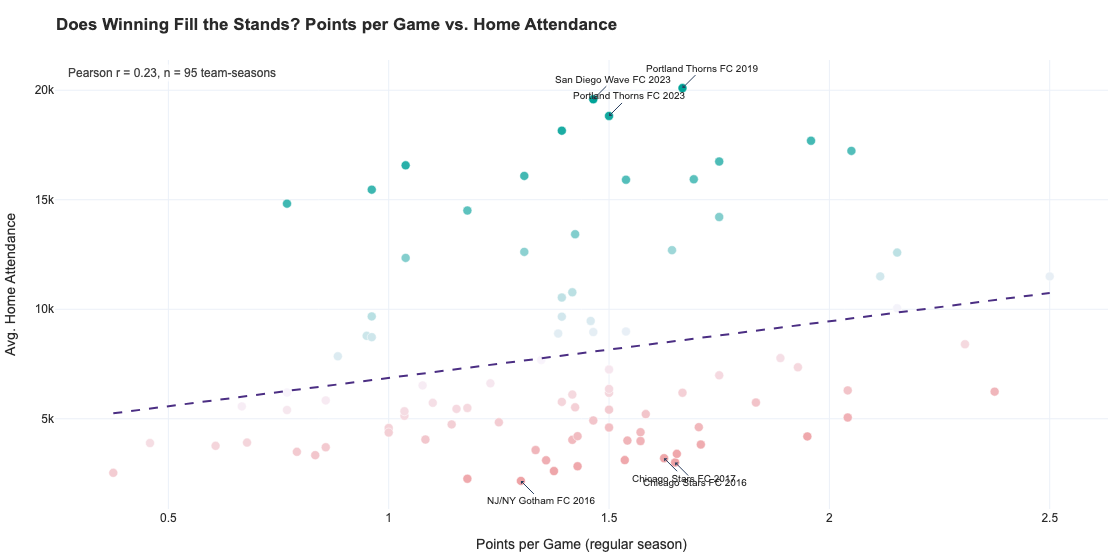

In [12]:
# 1. Points per game per team per season -- regular season only (playoffs are single-elimination
# and would add noisy, tiny-sample games to a team's record)
regular_season = nwsl_games[nwsl_games["knockout_game"] == False].dropna(subset=["home_score", "away_score"])

home_results = regular_season[["season_name", "home_team_id", "home_score", "away_score"]].rename(
    columns={"home_team_id": "team_id", "home_score": "gf", "away_score": "ga"}
)
away_results = regular_season[["season_name", "away_team_id", "away_score", "home_score"]].rename(
    columns={"away_team_id": "team_id", "away_score": "gf", "home_score": "ga"}
)
results = pd.concat([home_results, away_results])
results["points"] = np.select(
    [results["gf"] > results["ga"], results["gf"] == results["ga"]], [3, 1], default=0
)

season_record = (
    results.groupby(["season_name", "team_id"])
    .agg(games_played=("points", "count"), total_points=("points", "sum"))
    .reset_index()
)
season_record["ppg"] = season_record["total_points"] / season_record["games_played"]
season_record = season_record.merge(active_teams[["team_id", "team_name"]], on="team_id")

# 2. Merge with home attendance, restrict to completed seasons excluding 2020
season_attendance = active_att.groupby(["season_name", "team_name"])["attendance"].mean().reset_index()

success_vs_attendance = season_record.merge(season_attendance, on=["season_name", "team_name"])
success_vs_attendance = success_vs_attendance[
    (success_vs_attendance["season_name"] != 2020) & (success_vs_attendance["season_name"] <= 2025)
]

# 3. OLS trendline + Pearson correlation
slope, intercept, r_value = fit_trend(success_vs_attendance["ppg"], success_vs_attendance["attendance"])
success_vs_attendance["predicted_attendance"] = slope * success_vs_attendance["ppg"] + intercept
success_vs_attendance["residual"] = success_vs_attendance["attendance"] - success_vs_attendance["predicted_attendance"]
success_vs_attendance["team_season"] = (
    success_vs_attendance["team_name"] + " " + success_vs_attendance["season_name"].astype(str)
)

# 4. Plot
fig = px.scatter(
    success_vs_attendance,
    x="ppg",
    y="attendance",
    color="residual",
    color_continuous_scale=["#E34948", "#F8F4FC", "#00A398"],
    color_continuous_midpoint=0,
    hover_data={"team_season": True, "ppg": ":.2f", "attendance": ":.0f", "residual": False},
    labels={"ppg": "Points per Game (regular season)", "attendance": "Avg. Home Attendance"},
    title="<b>Does Winning Fill the Stands? Points per Game vs. Home Attendance</b>",
)
fig.update_traces(marker={"size": 9, "line": {"width": 0.5, "color": "white"}})

# OLS trendline
x_range = np.linspace(success_vs_attendance["ppg"].min(), success_vs_attendance["ppg"].max(), 50)
fig.add_scatter(
    x=x_range, y=slope * x_range + intercept, mode="lines",
    line={"color": "#4B2E83", "width": 2, "dash": "dash"}, name="OLS trend", showlegend=False,
)

# Label the biggest over/under-performers
outliers = pd.concat([
    success_vs_attendance.nlargest(3, "residual"),
    success_vs_attendance.nsmallest(3, "residual"),
])
for _, row in outliers.iterrows():
    fig.add_annotation(
        x=row["ppg"], y=row["attendance"], text=row["team_season"],
        showarrow=True, arrowhead=1, arrowsize=0.8, ax=20, ay=-20 if row["residual"] > 0 else 20,
        font={"size": 10},
    )

fig.add_annotation(
    text=f"Pearson r = {r_value:.2f}, n = {len(success_vs_attendance)} team-seasons",
    xref="paper", yref="paper", x=0.01, y=0.99, showarrow=False,
    font={"size": 12, "color": "#444444"}, bgcolor="rgba(255,255,255,0.7)",
)

fig = style_plotly_fig(fig)
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10}, coloraxis_showscale=False)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_success_vs_attendance.png"))
fig.show()

### The new-stadium honeymoon effect

Five active teams have moved into a clearly bigger or more purpose-built venue at some point in their history. 2020 (COVID) and the in-progress 2026 season are excluded.

| Team | Before | After |
|---|---|---|
| Kansas City Current | Field of Legends / Children's Mercy Park | **CPKC Stadium** (2024) first stadium ever purpose-built for a women's pro sports team |
| San Diego Wave FC | Torero Stadium (temporary, inaugural season) | Snapdragon Stadium (2023) |
| Seattle Reign FC | Memorial Stadium / Cheney Stadium | Lumen Field (2022) |
| Washington Spirit | Maryland SoccerPlex (suburban) | Audi Field (2021, downtown DC) |
| NJ/NY Gotham FC | Yurcak Field (college stadium) | Red Bull Arena (2021) |

Every one of these shows a large jump: from +62% (Kansas City) to +136% (Gotham FC). 

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/1149212735.py:60: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_new_stadium_effect.png"))


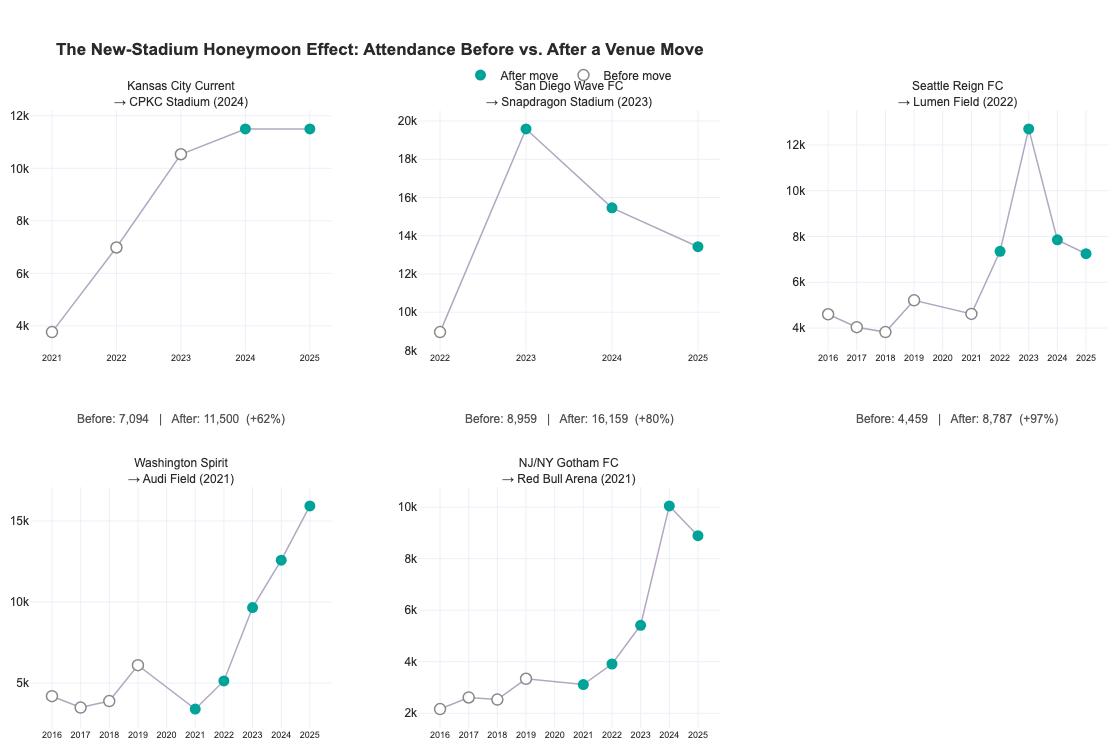

In [13]:
from plotly.subplots import make_subplots

# Team -> (move_year, new venue label). move_year = first season in the new venue.
stadium_moves = [
    ("Kansas City Current", 2024, "CPKC Stadium"),
    ("San Diego Wave FC", 2023, "Snapdragon Stadium"),
    ("Seattle Reign FC", 2022, "Lumen Field"),
    ("Washington Spirit", 2021, "Audi Field"),
    ("NJ/NY Gotham FC", 2021, "Red Bull Arena"),
]

team_season_att_moves = active_att[active_att["season_name"] != 2020]
team_season_att_moves = team_season_att_moves[team_season_att_moves["season_name"] <= 2025]
team_season_att_moves = team_season_att_moves.groupby(["team_name", "season_name"])["attendance"].mean().reset_index()

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f"{team}<br>→ {venue} ({move_year})" for team, move_year, venue in stadium_moves] + [""],
    horizontal_spacing=0.08, vertical_spacing=0.22,
)

for i, (team, move_year, venue) in enumerate(stadium_moves):
    row, col = (i // 3) + 1, (i % 3) + 1
    axis_num = "" if i == 0 else str(i + 1)
    sub = team_season_att_moves[team_season_att_moves["team_name"] == team].sort_values("season_name")
    sub["new_stadium"] = sub["season_name"] >= move_year

    before_avg = sub.loc[~sub["new_stadium"], "attendance"].mean()
    after_avg = sub.loc[sub["new_stadium"], "attendance"].mean()

    fig.add_scatter(
        x=sub["season_name"], y=sub["attendance"], mode="lines",
        line={"color": "#B0A8C0", "width": 1.5}, showlegend=False, row=row, col=col,
    )
    fig.add_scatter(
        x=sub.loc[sub["new_stadium"], "season_name"], y=sub.loc[sub["new_stadium"], "attendance"],
        mode="markers", marker={"color": "#00A398", "size": 11},
        name="After move", showlegend=(i == 0), legendgroup="after", row=row, col=col,
    )
    fig.add_scatter(
        x=sub.loc[~sub["new_stadium"], "season_name"], y=sub.loc[~sub["new_stadium"], "attendance"],
        mode="markers", marker={"color": "white", "size": 11, "line": {"color": "#888888", "width": 1.5}},
        name="Before move", showlegend=(i == 0), legendgroup="before", row=row, col=col,
    )

    fig.add_annotation(
        text=f"Before: {before_avg:,.0f}   |   After: {after_avg:,.0f}  ({(after_avg / before_avg - 1) * 100:+.0f}%)",
        xref=f"x{axis_num} domain", yref=f"y{axis_num} domain", x=0.5, y=-0.32, showarrow=False,
        font={"size": 10, "color": "#555555"}, row=row, col=col,
    )

fig = style_plotly_fig(fig)
fig.update_layout(
    title="<b>The New-Stadium Honeymoon Effect: Attendance Before vs. After a Venue Move</b>",
    width=1050, height=750, margin={"t": 110, "b": 20, "l": 10, "r": 10},
    legend={"orientation": "h", "y": 1.08, "x": 0.5, "xanchor": "center"},
)
fig.update_annotations(font_size=12)
fig.update_xaxes(dtick=1, tickfont={"size": 9})
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_new_stadium_effect.png"))
fig.show()

## Public interest: closing the gap with MLS

Uses `data/raw/time_series_mens_womens.csv` monthly Google Trends search interest (2012-2026) for MLS, NWSL, and the US men's/women's national teams. No API needed, data download

In [14]:
DATA_RAW_DIR = os.path.join("..", "data", "raw")

trends = pd.read_csv(os.path.join(DATA_RAW_DIR, "time_series_mens_womens.csv"))
trends["Time"] = pd.to_datetime(trends["Time"])
trends["year"] = trends["Time"].dt.year
trends = trends.rename(columns={
    "National Women's Soccer League": "nwsl_interest",
    "United States women's national soccer team": "uswnt_interest",
    "MLS": "mls_interest",
})

yearly_trends = trends.groupby("year")[["mls_interest", "nwsl_interest", "uswnt_interest"]].mean()

### Is NWSL closing the interest gap with MLS?

Same Trends data, simpler framing: NWSL's search interest as a **% of MLS's**, year by year. A rising line means NWSL is closing the gap; flat means both are growing at the same rate.

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/3860524727.py:13: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_interest_gap.png"))


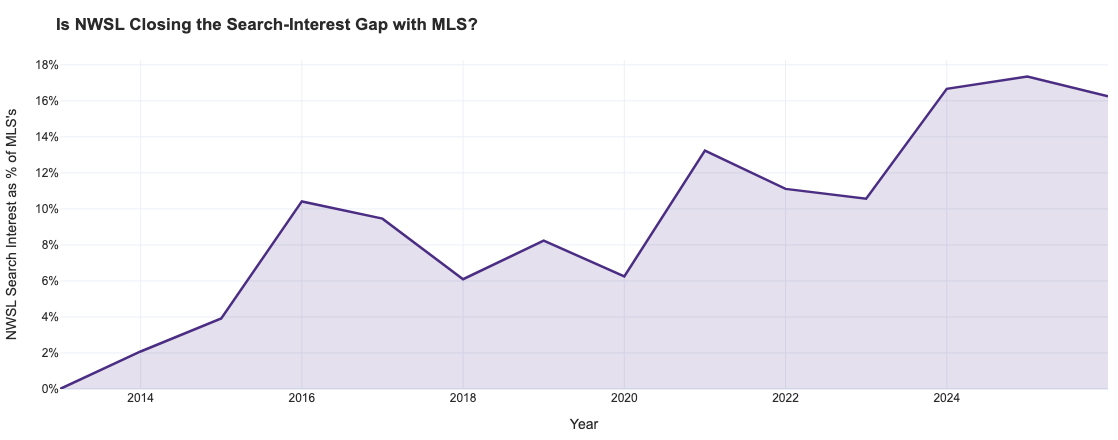

In [15]:
yearly_trends["nwsl_pct_of_mls"] = yearly_trends["nwsl_interest"] / yearly_trends["mls_interest"] * 100
gap = yearly_trends[yearly_trends.index >= 2013]

fig = px.area(
    gap, x=gap.index, y="nwsl_pct_of_mls",
    labels={"nwsl_pct_of_mls": "NWSL Search Interest as % of MLS's", "year": "Year"},
    title="<b>Is NWSL Closing the Search-Interest Gap with MLS?</b>",
)
fig.update_traces(line={"color": "#4B2E83", "width": 2.5}, fillcolor="rgba(75,46,131,0.15)")
fig = style_plotly_fig(fig)
fig.update_layout(height=440, margin={"t": 60, "b": 40, "l": 10, "r": 10})
fig.update_yaxes(ticksuffix="%")
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_interest_gap.png"))
fig.show()

## Market size vs. attendance: which markets are over- or under-tapped?

Metro population isn't in any pulled dataset, so using a **hand-built lookup table**, one row per active team's metro area, using approximate 2023 Census Bureau MSA population estimates. 
Note:
- **Bay FC** plays in San Jose, but markets itself to the whole Bay Area, so used the entire Bay Area population.
- **NJ/NY Gotham FC** plays in Harrison, NJ but draws from the full New York metro and is moving to Queens, so used the New York-Newark-Jersey City MSA (~19.5M).
- **Boston Legacy FC** and **Denver Summit FC** are 2026 expansion teams with no completed season, so their attendance should be taken with a grain of salt.

Population is log-scaled on the x-axis (NYC's metro is ~14x Louisville's), with an OLS trendline fit in log-population space and the biggest residuals labeled. 

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/4248371682.py:82: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_market_size_vs_attendance.png"))


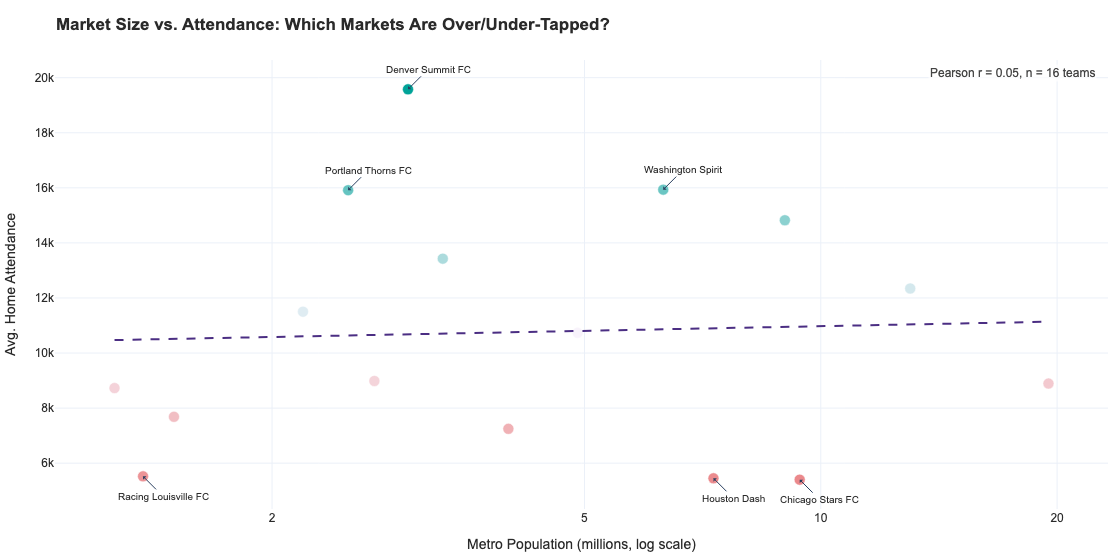

In [16]:
# 1. Hand-built metro population lookup (millions, ~2023 Census Bureau MSA estimates)
METRO_POPULATION_MILLIONS = {
    "Orlando Pride": 2.7,
    "NJ/NY Gotham FC": 19.5,
    "Houston Dash": 7.3,
    "Washington Spirit": 6.3,
    "Seattle Reign FC": 4.0,
    "Chicago Stars FC": 9.4,
    "Portland Thorns FC": 2.5,
    "North Carolina Courage": 1.5,
    "Utah Royals FC": 1.26,
    "Kansas City Current": 2.19,
    "Racing Louisville FC": 1.37,
    "San Diego Wave FC": 3.3,
    "Angel City FC": 13.0,
    "Bay FC": 9.0,
    "Boston Legacy FC": 4.9,
    "Denver Summit FC": 2.98,
}

# 2. Attendance: 2025 avg. for established teams; 2026 partial avg. for the 2 brand-new teams
active_teams_market = teams[(teams["league"] == "nwsl") & (teams["year_of_death"].isna())].copy()
nwsl_games_market = games[games["league"] == "nwsl"].dropna(subset=["attendance", "home_team_id"])
nwsl_games_market = nwsl_games_market.merge(
    active_teams_market[["team_id", "team_name"]], left_on="home_team_id", right_on="team_id"
)

att_2025_market = nwsl_games_market[nwsl_games_market["season_name"] == 2025].groupby("team_name")["attendance"].mean()
att_2026_market = nwsl_games_market[nwsl_games_market["season_name"] == 2026].groupby("team_name")["attendance"].mean()

market = pd.DataFrame({"team_name": list(METRO_POPULATION_MILLIONS.keys())})
market["metro_population_millions"] = market["team_name"].map(METRO_POPULATION_MILLIONS)
market["avg_attendance"] = market["team_name"].map(att_2025_market)
market["data_basis"] = "2025"
missing_2025 = market["avg_attendance"].isna()
market.loc[missing_2025, "avg_attendance"] = market.loc[missing_2025, "team_name"].map(att_2026_market)
market.loc[missing_2025, "data_basis"] = "2026 (partial)"
market = market.dropna(subset=["avg_attendance"])

# 3. Log-transform population manually
market["log_pop"] = np.log10(market["metro_population_millions"])
slope, intercept, r_value = fit_trend(market["log_pop"], market["avg_attendance"])
market["predicted"] = slope * market["log_pop"] + intercept
market["residual"] = market["avg_attendance"] - market["predicted"]

# 4. Plot
fig = px.scatter(
    market, x="log_pop", y="avg_attendance",
    color="residual", color_continuous_scale=["#E34948", "#F8F4FC", "#00A398"], color_continuous_midpoint=0,
    hover_data={"team_name": True, "data_basis": True, "metro_population_millions": ":.2f", "avg_attendance": ":.0f", "residual": False, "log_pop": False},
    labels={"log_pop": "Metro Population (millions, log scale)", "avg_attendance": "Avg. Home Attendance"},
    title="<b>Market Size vs. Attendance: Which Markets Are Over/Under-Tapped?</b>",
)
fig.update_traces(marker={"size": 11, "line": {"width": 0.5, "color": "white"}})

x_range = np.linspace(market["log_pop"].min(), market["log_pop"].max(), 50)
fig.add_scatter(
    x=x_range, y=slope * x_range + intercept, mode="lines",
    line={"color": "#4B2E83", "width": 2, "dash": "dash"}, showlegend=False,
)

outliers = pd.concat([market.nlargest(3, "residual"), market.nsmallest(3, "residual")])
for _, row in outliers.iterrows():
    fig.add_annotation(
        x=row["log_pop"], y=row["avg_attendance"], text=row["team_name"],
        showarrow=True, arrowhead=1, arrowsize=0.8, ax=20, ay=-20 if row["residual"] > 0 else 20,
        font={"size": 10},
    )

fig.add_annotation(
    text=f"Pearson r = {r_value:.2f}, n = {len(market)} teams",
    xref="paper", yref="paper", x=0.99, y=0.99, xanchor="right", yanchor="top", showarrow=False,
    font={"size": 12, "color": "#444444"}, bgcolor="rgba(255,255,255,0.7)",
)

# Manual log-style tick labels on the (actually linear) x-axis
tick_pop_values = [1, 2, 5, 10, 20]
fig.update_xaxes(tickvals=[np.log10(v) for v in tick_pop_values], ticktext=[str(v) for v in tick_pop_values])

fig = style_plotly_fig(fig)
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10}, coloraxis_showscale=False)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_market_size_vs_attendance.png"))
fig.show()

## Adding the MLS back in

In [17]:
import plotly.graph_objects as go

# 1. MLS points per game per team per season -- identical method to the NWSL version above
active_mls = teams[(teams["league"] == "mls") & (teams["year_of_death"].isna())].copy()
mls_games = games[games["league"] == "mls"]

mls_regular_season = mls_games[mls_games["knockout_game"] == False].dropna(subset=["home_score", "away_score"])
mls_home_results = mls_regular_season[["season_name", "home_team_id", "home_score", "away_score"]].rename(
    columns={"home_team_id": "team_id", "home_score": "gf", "away_score": "ga"}
)
mls_away_results = mls_regular_season[["season_name", "away_team_id", "away_score", "home_score"]].rename(
    columns={"away_team_id": "team_id", "away_score": "gf", "home_score": "ga"}
)
mls_results = pd.concat([mls_home_results, mls_away_results])
mls_results["points"] = np.select(
    [mls_results["gf"] > mls_results["ga"], mls_results["gf"] == mls_results["ga"]], [3, 1], default=0
)
mls_season_record = (
    mls_results.groupby(["season_name", "team_id"])
    .agg(games_played=("points", "count"), total_points=("points", "sum"))
    .reset_index()
)
mls_season_record["ppg"] = mls_season_record["total_points"] / mls_season_record["games_played"]
mls_season_record = mls_season_record.merge(active_mls[["team_id", "team_name"]], on="team_id")

# 2. Attendance, same window as the NWSL version (2020 excluded, complete seasons only)
mls_att = mls_games.dropna(subset=["attendance", "home_team_id"]).merge(
    active_mls[["team_id", "team_name"]], left_on="home_team_id", right_on="team_id"
)
mls_season_attendance = mls_att.groupby(["season_name", "team_name"])["attendance"].mean().reset_index()

mls_success_vs_attendance = mls_season_record.merge(mls_season_attendance, on=["season_name", "team_name"])
mls_success_vs_attendance = mls_success_vs_attendance[
    (mls_success_vs_attendance["season_name"] != 2020) & (mls_success_vs_attendance["season_name"] <= 2025)
]
mls_success_vs_attendance["league"] = "MLS"

nwsl_compare = success_vs_attendance[["season_name", "team_name", "ppg", "attendance"]].copy()
nwsl_compare["league"] = "NWSL"
mls_compare = mls_success_vs_attendance[["season_name", "team_name", "ppg", "attendance"]].copy()
mls_compare["league"] = "MLS"  

both_leagues = pd.concat([nwsl_compare, mls_compare])

# 3. Trendline + r for each league separately
fig = go.Figure()
league_colors = {"NWSL": "#4B2E83", "MLS": "#00A398"}
summary_lines = []
for league_name, color in league_colors.items():
    sub = both_leagues[both_leagues["league"] == league_name]
    slope, intercept, r_value = fit_trend(sub["ppg"], sub["attendance"])
    x_range = np.linspace(sub["ppg"].min(), sub["ppg"].max(), 50)
    fig.add_scatter(
        x=sub["ppg"], y=sub["attendance"], mode="markers", name=league_name,
        marker={"color": color, "size": 7, "opacity": 0.55},
    )
    fig.add_scatter(
        x=x_range, y=slope * x_range + intercept, mode="lines", name=f"{league_name} trend",
        line={"color": color, "width": 2.5, "dash": "dash"}, showlegend=False,
    )
    summary_lines.append(f"{league_name}: r = {r_value:.2f}, n = {len(sub)}")
    print(f"{league_name} points-per-game vs. attendance: r={r_value:.3f}, n={len(sub)}")

fig.add_annotation(
    text="<br>".join(summary_lines), xref="paper", yref="paper", x=0.01, y=0.99, showarrow=False,
    align="left", font={"size": 12, "color": "#444444"}, bgcolor="rgba(255,255,255,0.75)",
)
fig.update_layout(
    title="<b>Winning vs. Attendance: NWSL vs. MLS</b>",
    xaxis_title="Points per Game (regular season)", yaxis_title="Avg. Home Attendance",
)
fig = style_plotly_fig(fig)
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10},
                   legend={"orientation": "h", "y": -0.15, "x": 0.5, "xanchor": "center"})
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_success_vs_attendance.png"))
fig.show()

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/1034121741.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_success_vs_attendance.png"))


NWSL points-per-game vs. attendance: r=0.234, n=95
MLS points-per-game vs. attendance: r=0.158, n=288


### Market size vs. attendance, both leagues

Same hand-built metro-population approach as the NWSL chart, extended to all 30 active MLS markets.

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/3930780594.py:65: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_market_size.png"))


NWSL market size vs. attendance: r=0.047, n=16
MLS market size vs. attendance: r=-0.192, n=30


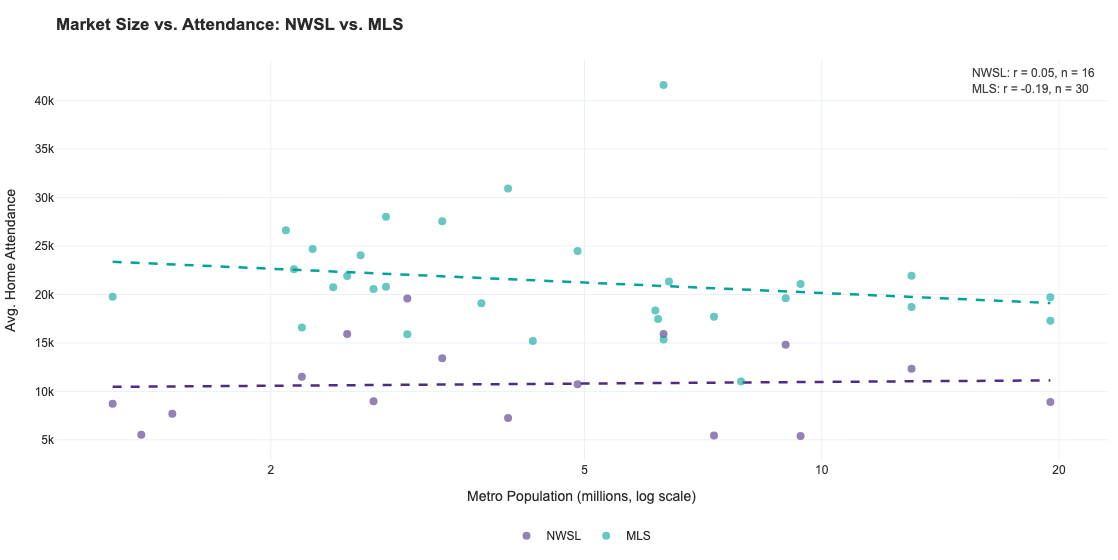

In [18]:
# Hand-built metro population lookup for MLS's 30 active markets (millions, ~2023
# Census/StatCan estimates): same approach and, where a metro is shared with an NWSL
# team already in the lookup (e.g. LA, NYC, Seattle), the same population figure.
METRO_POPULATION_MILLIONS_MLS = {
    "San Jose Earthquakes": 9.0, "Colorado Rapids": 2.98, "Columbus Crew": 2.14,
    "FC Dallas": 7.9, "Vancouver Whitecaps FC": 2.6, "LA Galaxy": 13.0,
    "Toronto FC": 6.4, "Seattle Sounders FC": 4.0, "Real Salt Lake": 1.26,
    "Sporting Kansas City": 2.19, "Houston Dynamo FC": 7.3, "New York Red Bulls": 19.5,
    "Portland Timbers FC": 2.5, "New England Revolution": 4.9, "Philadelphia Union": 6.2,
    "CF Montréal": 4.3, "D.C. United": 6.3, "Chicago Fire FC": 9.4,
    "New York City FC": 19.5, "Orlando City SC": 2.7, "Atlanta United FC": 6.3,
    "Minnesota United FC": 3.7, "Los Angeles FC": 13.0, "FC Cincinnati": 2.26,
    "Nashville SC": 2.09, "Inter Miami CF": 6.15, "Austin FC": 2.4,
    "Charlotte FC": 2.8, "St. Louis City SC": 2.8, "San Diego FC": 3.3,
}

mls_att_2025 = mls_att[mls_att["season_name"] == 2025].groupby("team_name")["attendance"].mean()
mls_att_2024 = mls_att[mls_att["season_name"] == 2024].groupby("team_name")["attendance"].mean()

mls_market = pd.DataFrame({"team_name": list(METRO_POPULATION_MILLIONS_MLS.keys())})
mls_market["metro_population_millions"] = mls_market["team_name"].map(METRO_POPULATION_MILLIONS_MLS)
mls_market["avg_attendance"] = mls_market["team_name"].map(mls_att_2025)
mls_market.loc[mls_market["avg_attendance"].isna(), "avg_attendance"] = mls_market["team_name"].map(mls_att_2024)
mls_market = mls_market.dropna(subset=["avg_attendance"])
mls_market["log_pop"] = np.log10(mls_market["metro_population_millions"])
mls_market["league"] = "MLS"

nwsl_market_compare = market[["team_name", "log_pop", "avg_attendance"]].copy()
nwsl_market_compare["league"] = "NWSL"
mls_market_compare = mls_market[["team_name", "log_pop", "avg_attendance"]].copy()
mls_market_compare["league"] = "MLS"  # same bug as the win%% cell -- was missing
both_markets = pd.concat([nwsl_market_compare, mls_market_compare])

fig = go.Figure()
market_summary_lines = []
for league_name, color in league_colors.items():
    sub = both_markets[both_markets["league"] == league_name]
    slope, intercept, r_value = fit_trend(sub["log_pop"], sub["avg_attendance"])
    x_range = np.linspace(sub["log_pop"].min(), sub["log_pop"].max(), 50)
    fig.add_scatter(
        x=sub["log_pop"], y=sub["avg_attendance"], mode="markers", name=league_name,
        marker={"color": color, "size": 8, "opacity": 0.6},
    )
    fig.add_scatter(
        x=x_range, y=slope * x_range + intercept, mode="lines", name=f"{league_name} trend",
        line={"color": color, "width": 2.5, "dash": "dash"}, showlegend=False,
    )
    market_summary_lines.append(f"{league_name}: r = {r_value:.2f}, n = {len(sub)}")
    print(f"{league_name} market size vs. attendance: r={r_value:.3f}, n={len(sub)}")

fig.add_annotation(
    text="<br>".join(market_summary_lines), xref="paper", yref="paper", x=0.99, y=0.99,
    xanchor="right", yanchor="top", showarrow=False, align="left",
    font={"size": 12, "color": "#444444"}, bgcolor="rgba(255,255,255,0.75)",
)
tick_pop_values = [1, 2, 5, 10, 20]
fig.update_xaxes(tickvals=[np.log10(v) for v in tick_pop_values], ticktext=[str(v) for v in tick_pop_values])
fig.update_layout(
    title="<b>Market Size vs. Attendance: NWSL vs. MLS</b>",
    xaxis_title="Metro Population (millions, log scale)", yaxis_title="Avg. Home Attendance",
)
fig = style_plotly_fig(fig)
fig.update_layout(height=560, margin={"t": 60, "b": 40, "l": 10, "r": 10},
                   legend={"orientation": "h", "y": -0.15, "x": 0.5, "xanchor": "center"})
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_vs_mls_market_size.png"))
fig.show()

**Winning predicts attendance about as weakly in both leagues** and if anything, slightly *more* in the NWSL, not less. **Market size doesn't predict attendance in either league** and in MLS the relationship is (non-significantly) negative: NYCFC and the Red Bulls, sitting in the largest metro in either league by a wide margin, draw fewer fans than Nashville, Charlotte, or Cincinnati. That's not an NWSL quirk. It's true of MLS too.

## What actually predicts attendance: confounders first, then one regression

`rivalry_flag` is Portland + Seattle = 1, everyone else = 0 because it's the primary established rivalry

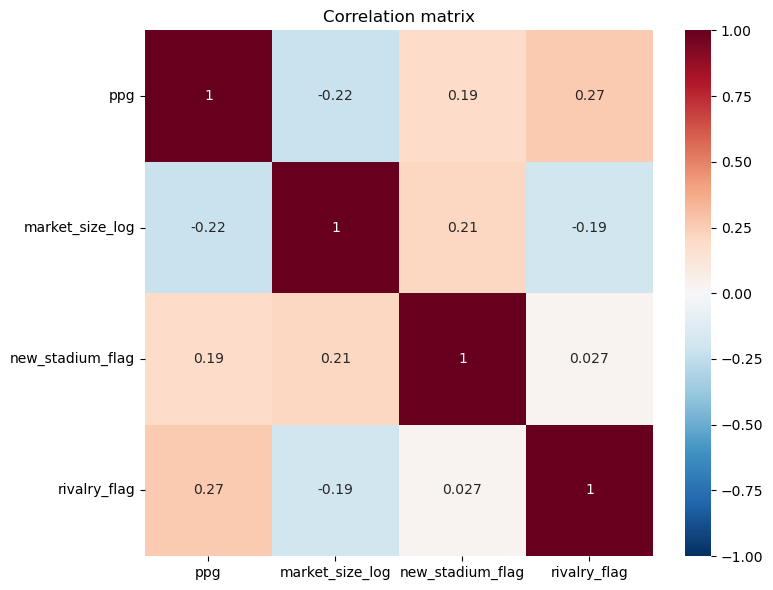

In [30]:
reg_df = success_vs_attendance[["season_name", "team_name", "ppg", "attendance"]].copy()

market_size_by_team = market.set_index("team_name")["log_pop"]
reg_df["market_size_log"] = reg_df["team_name"].map(market_size_by_team)

# new_stadium_flag: 1 from the season a team moved into its new venue onward
move_year_by_team = {team: year for team, year, _ in stadium_moves}
reg_df["new_stadium_flag"] = reg_df.apply(
    lambda r: int(r["team_name"] in move_year_by_team and r["season_name"] >= move_year_by_team[r["team_name"]]),
    axis=1,
)

# rivalry_flag: only Cascadia (Portland/Seattle) 
reg_df["rivalry_flag"] = reg_df["team_name"].isin(["Portland Thorns FC", "Seattle Reign FC"]).astype(int)

predictors = ["ppg", "market_size_log", "new_stadium_flag", "rivalry_flag"]
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix")
plt.tight_layout()

Largest correlation: ppg & rivalry_flag @ 0.27 -> nothing significant

### The regression, plus a classification check

1. **Linear regression** (`LinearRegression`) predicting the actual attendance number
2. **Logistic regression** (`LogisticRegression`) predicting a simpler yes/no version of the same question -- did this team-season draw an above-median crowd? 

                            OLS Regression Results                            
Dep. Variable:             attendance   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     2.955
Date:                Wed, 19 Aug 2026   Prob (F-statistic):             0.0256
Time:                        14:58:00   Log-Likelihood:                -743.79
No. Observations:                  76   AIC:                             1498.
Df Residuals:                      71   BIC:                             1509.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             6263.2670   2297.983  

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/2996323206.py:75: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_attendance_confusion_matrix.png"))


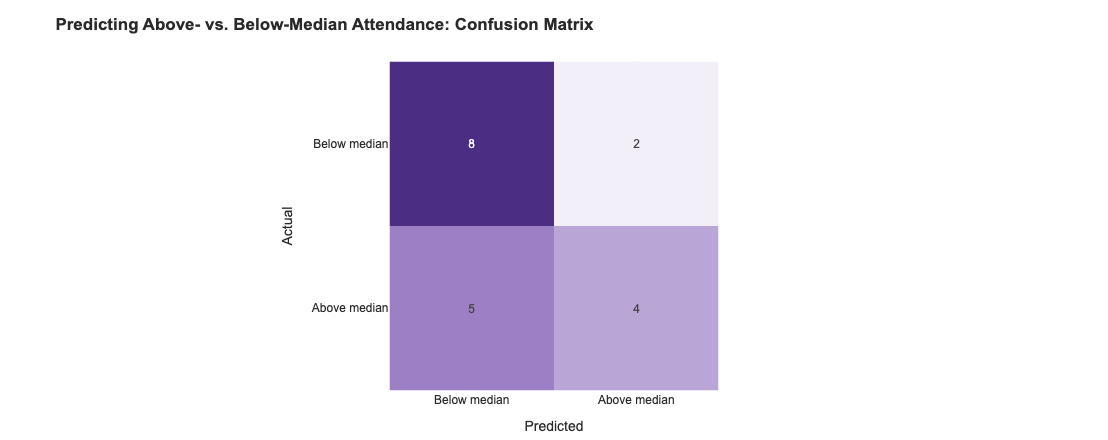

In [36]:
# ---------------------------------------------------------------------------
# Linear Regression:
# Predicting attendance
# ---------------------------------------------------------------------------
X = reg_df[predictors]
y_continuous = reg_df["attendance"]

X_train, X_test, y_train, y_test = train_test_split(X, y_continuous, test_size=0.2, random_state=42)

# 2. Add intercept constant to both sets separately
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# 3. Fit OLS only on the training set
ols_model = sm.OLS(y_train, X_train_sm)
ols_results = ols_model.fit()
print(ols_results.summary())

# 4. Predict and evaluate on the holdout test set
y_pred = ols_results.predict(X_test_sm)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R²: {test_r2:.4f}")

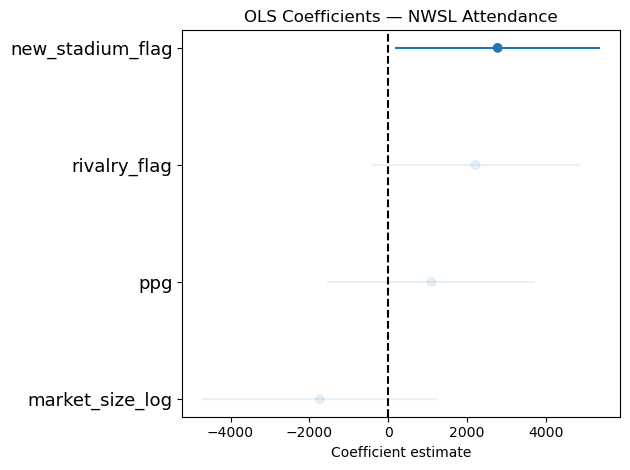

In [42]:
R = parse_coefs(ols_results)

plt.hlines(R.index, R.low_b, R.up_b, alpha=R.alpha)
plt.scatter(R.coef, R.index, alpha=R.alpha)
plt.axvline(0, linestyle="--", color="black")
plt.yticks(R.index, R.vari, fontsize=13)
plt.xlabel("Coefficient estimate")
plt.title("OLS Coefficients — NWSL Attendance")
plt.tight_layout()

## Residual Diagnostics

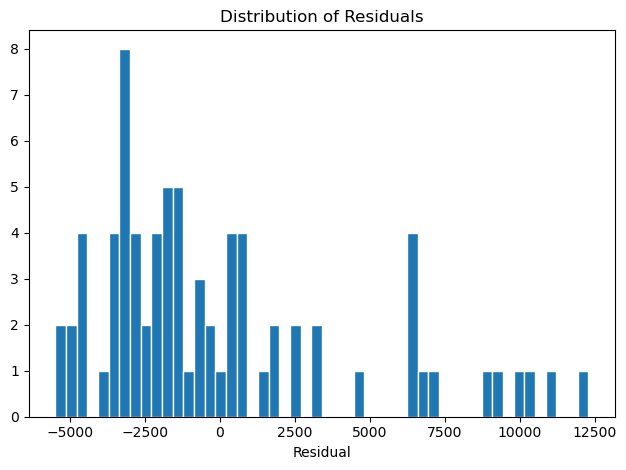

In [43]:
residuals = ols_results.resid

plt.hist(residuals, bins=50, edgecolor='white')
plt.xlabel('Residual')
plt.title('Distribution of Residuals')
plt.tight_layout()

Optimization terminated successfully.
         Current function value: 0.544485
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             attendance   No. Observations:                   76
Model:                          Logit   Df Residuals:                       71
Method:                           MLE   Df Model:                            4
Date:                Wed, 19 Aug 2026   Pseudo R-squ.:                  0.2145
Time:                        15:08:07   Log-Likelihood:                -41.381
converged:                       True   LL-Null:                       -52.679
Covariance Type:            nonrobust   LLR p-value:                 0.0001524
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.1389      1.205     -0.945      0.345      -3.501       1.223
ppg        

/var/folders/2y/rz_rt3v15kv2qz95_7stn2_r0000gn/T/ipykernel_91796/3384035377.py:43: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_attendance_confusion_matrix.png"))


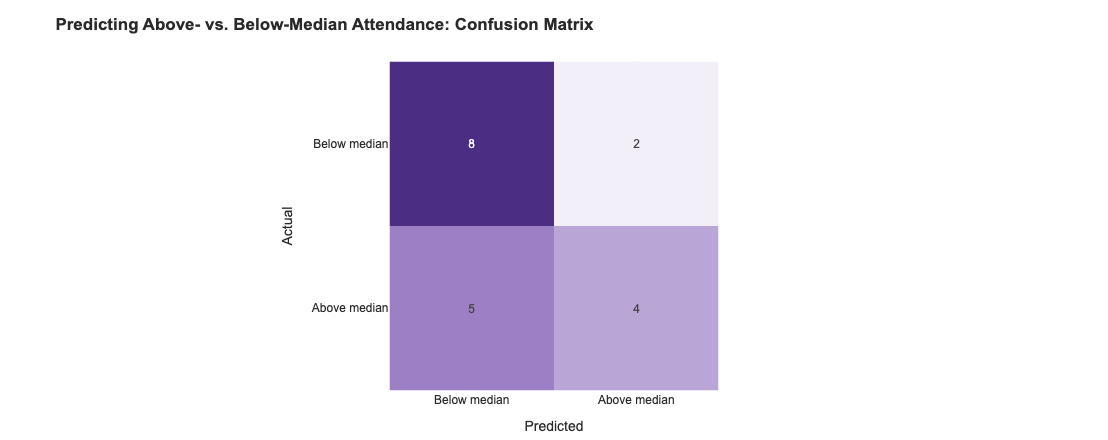

In [47]:
# ---------------------------------------------------------------------------
#  Logistic regression:
#  did this team-season draw an above-median crowd? Same train/test split
# ---------------------------------------------------------------------------
median_attendance = reg_df["attendance"].median()
y_binary = (reg_df["attendance"] > median_attendance).astype(int)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# logreg = LogisticRegression()
# logreg.fit(Xb_train, yb_train)
# yb_pred = logreg.predict(Xb_test)
Xb_train = sm.add_constant(Xb_train)

logit_model = sm.Logit(yb_train, Xb_train)
logit_results = logit_model.fit()

y_pred_probs = logit_results.predict(Xb_train)
print(logit_results.summary())

cm = confusion_matrix(yb_test, yb_pred)
print("\nConfusion matrix (rows = actual, cols = predicted; order = [below-median, above-median]):")
print(cm)
print(f"\nAccuracy:  {accuracy_score(yb_test, yb_pred):.2f}")
print(f"Precision: {precision_score(yb_test, yb_pred):.2f}")
print(f"Recall:    {recall_score(yb_test, yb_pred):.2f}")
print(f"F1:        {f1_score(yb_test, yb_pred):.2f}")

# Plot the confusion matrix
cm_labels = ["Below median", "Above median"]
fig = px.imshow(
    cm, x=cm_labels, y=cm_labels, text_auto=True,
    color_continuous_scale=NWSL_SEQUENTIAL,
    labels={"x": "Predicted", "y": "Actual", "color": "Team-seasons"},
    title="<b>Predicting Above- vs. Below-Median Attendance: Confusion Matrix</b>",
)
fig = style_plotly_fig(fig)
fig.update_layout(height=440, margin={"t": 60, "b": 40, "l": 10, "r": 10}, coloraxis_showscale=False)
fig.write_image(os.path.join(OUTPUT_DIR, "nwsl_attendance_confusion_matrix.png"))
fig.show()

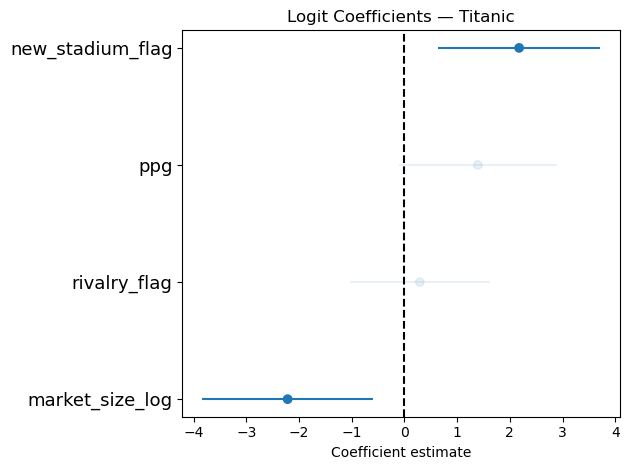

In [46]:
R = parse_coefs(logit_results)

plt.hlines(R.index, R.low_b, R.up_b, alpha=R.alpha)
plt.scatter(R.coef, R.index, alpha=R.alpha)
plt.axvline(0, linestyle="--", color="black")
plt.yticks(R.index, R.vari, fontsize=13)
plt.xlabel("Coefficient estimate")
plt.title("Logit Coefficients — Over/Underperforming Expectations")
plt.tight_layout()